
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

Juan Sebastian Gallon 1001015809

In [22]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [23]:
# 1. Profundidades del pico

# voy a obtener el pico de maxima profundidad
profun_max = df[df['isla'] == 'Torgersen']['profundidad_pico (mm)'].max()

# voy a obtener el pico de minima profundidad
profun_min = df['profundidad_pico (mm)'].min()

print("Profundidad de pico máxima :", profun_max)
print("Profundidad de pico mínima :", profun_min)

Profundidad de pico máxima : 21.5
Profundidad de pico mínima : 13.1


In [24]:
# 2. Información del pinguino más gordo

# voy a obtener el valor donde la masa es maxima
masa_max = np.argmax(df['masa_corporal (g)'])

#obtengo las listas respectivas para cada dato necesario del pinguino
isla = df.loc[masa_max, 'isla']
especie = df.loc[masa_max, 'especie']
genero = df.loc[masa_max, 'genero']

print('pinguino, especie y su isla ')
print("masa:", masa_max)
print("Isla :", isla)
print("Especie :", especie)
print("Género:", genero)


pinguino, especie y su isla 
masa: 231
Isla : Biscoe
Especie : Gentoo
Género: Male


In [25]:
# 3. Masa corporal promedio de todos los pingünos macho que no son gentoo

#uso .mean() para encontarr el promedio y pandas con & para eliminar a Gentoo y solo dejar los machos de otra especie en el promedio

promedio = df[(df['especie'] != 'Gentoo') & (df['genero'] == 'Male')]['masa_corporal (g)'].mean()

print("La masa corporal media de los pinguinos difererentes a Gentoo es:", promedio)


La masa corporal media de los pinguinos difererentes a Gentoo es: 4010.2803738317757


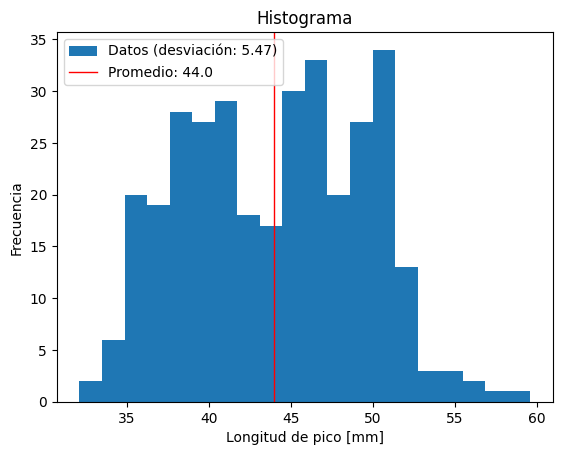

In [26]:
# 4. Grafica de distribución de longitud de pico

# Obtenemos promedio y la desviacion de los datos en longitud_pico

promedio_longitud = df['longitud_pico (mm)'].mean()
desv_longitud = df['longitud_pico (mm)'].std()

#hago el histograma

plt.hist(df['longitud_pico (mm)'], bins=20, label=f'Datos (desviación: {desv_longitud:.2f})')
plt.axvline(promedio_longitud, color='red', linewidth=1, label=f'Promedio: {promedio_longitud:.1f}')
plt.title('Histograma')
plt.xlabel('Longitud de pico [mm]')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [27]:
# 5. Islas y especies
islas_totales = df['isla'].unique()
especies_totales = df['especie'].unique()
print(especies_totales)
print(islas_totales)

['Adelie' 'Chinstrap' 'Gentoo']
['Torgersen' 'Biscoe' 'Dream']


5 REGULAR... HACER UN HIST DE FRECUENCIAS POR SPECIE....

MUY BIEN. NOTA 4.6